In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
driver = pd.read_csv('../../data/merged/data.csv')
driver = driver[driver['source'] == 2020][['image_id']]

In [4]:
score = pd.read_csv('../../score/version7.csv')

In [5]:
data = driver.merge(score, on='image_id')
data = data.groupby(['image_id','label']).mean().reset_index()

In [6]:
data['preds'] = np.array(data.iloc[:,2:7]).argmax(axis=1)

In [7]:
data['acc'] = data['preds'] == data['label']

In [8]:
data.groupby('label')['acc'].agg(['count','mean'])

,count,mean
label,,
0,1087,0.696412
1,2189,0.795797
2,2386,0.825650
3,13158,0.968460
4,2577,0.721381


In [9]:
data['acc'].mean()

0.8912931719399916

In [10]:
print(classification_report(data['label'], data['preds']))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68      1087
           1       0.86      0.80      0.83      2189
           2       0.80      0.83      0.81      2386
           3       0.96      0.97      0.96     13158
           4       0.75      0.72      0.74      2577

    accuracy                           0.89     21397
   macro avg       0.81      0.80      0.80     21397
weighted avg       0.89      0.89      0.89     21397



In [11]:
cf = confusion_matrix(data['label'], data['preds'], normalize='true')

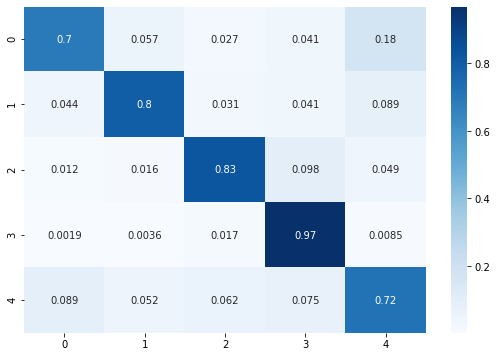

In [12]:
plt.figure(figsize=(9,6))
sns.heatmap(cf, annot=True, cmap='Blues')
plt.show()

In [13]:
data.preds.value_counts()

3    13304
4     2475
2     2458
1     2025
0     1135
Name: preds, dtype: int64